### Imports

In [14]:
#Required modules and setting variables
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
import joblib

### Loading Data

In [15]:
#Load data and save in pandas DataFrame
datafolder="../../astro/CALplots/"
eminstr=("-5.0")

datapath=datafolder+"fitspectra-HeP_fitsave%s.dat"%eminstr
data = pd.DataFrame()
with open(datapath, "rb") as file:
    foundfiles,globpardict,pflxs,pfs,x2s,x2dict,vx2s,vx2dict,rx2s,rx2dict,px2s,px2dict,hx2s,hx2dict,fx2s,fx2dict,qx2s,qx2dict,vfx2s,vfx2dict,likes,likedict,mlikes,mlikedict,tlikes,tlikedict,qlikes,qlikedict,tss,tsdict,faultfiles,faultpardict,corrfactlist = pickle.load(file)
    globpardict["Y"]=likes
    # globpardict["Y2"]=fx2s
    # globpardict["Y3"]=px2s
    # globpardict["Y4"]=hx2s
    data = pd.DataFrame.from_dict(globpardict)
print(data.shape)
print(data.head(3))
print(np.min(data["Y"]))

(5926, 18)
   sindex   nuccut  diffexp  lowindx  lowexp  lowdiffbreak  lowdiffbreaksoft  \
0  2.9170  31.0000   0.5181   2.1036  0.1400       11.7473            0.0934   
1  2.9257  33.1363   0.5123   2.1038  0.1227       11.9974            0.1015   
2  2.9156  32.3461   0.5228   2.0989  0.1438       11.6415            0.0875   

   diffnorm    DE    DR    alvel  highexp  diffbreak  diffbreaksoft  lowbreak  \
0    3.7165  5.98  8.49  17.6047   0.0002   490.0657         0.3609   26.3946   
1    3.7727  5.97  7.91  17.4856   0.0001   537.9361         0.3541   26.0532   
2    3.6924  5.77  8.19  17.9467   0.0001   534.4408         0.3658   26.7425   

   lowsoft  spiralwidth          Y  
0   0.1798       0.0803  23.968999  
1   0.1863       0.0690  14.991390  
2   0.1824       0.1103  11.476937  
10.852074198437888


### Missing Data? Infinite values?

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5926 entries, 0 to 5925
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sindex            5926 non-null   float64
 1   nuccut            5926 non-null   float64
 2   diffexp           5926 non-null   float64
 3   lowindx           5926 non-null   float64
 4   lowexp            5926 non-null   float64
 5   lowdiffbreak      5926 non-null   float64
 6   lowdiffbreaksoft  5926 non-null   float64
 7   diffnorm          5926 non-null   float64
 8   DE                5926 non-null   float64
 9   DR                5926 non-null   float64
 10  alvel             5926 non-null   float64
 11  highexp           5926 non-null   float64
 12  diffbreak         5926 non-null   float64
 13  diffbreaksoft     5926 non-null   float64
 14  lowbreak          5926 non-null   float64
 15  lowsoft           5926 non-null   float64
 16  spiralwidth       5926 non-null   float64


In [17]:
data.isnull().any()

sindex              False
nuccut              False
diffexp             False
lowindx             False
lowexp              False
lowdiffbreak        False
lowdiffbreaksoft    False
diffnorm            False
DE                  False
DR                  False
alvel               False
highexp             False
diffbreak           False
diffbreaksoft       False
lowbreak            False
lowsoft             False
spiralwidth         False
Y                   False
dtype: bool

In [18]:
data.isin([np.inf, -np.inf]).sum()

sindex                0
nuccut                0
diffexp               0
lowindx               0
lowexp                0
lowdiffbreak          0
lowdiffbreaksoft      0
diffnorm              0
DE                    0
DR                    0
alvel                 0
highexp               0
diffbreak             0
diffbreaksoft         0
lowbreak              0
lowsoft               0
spiralwidth           0
Y                   657
dtype: int64

In [19]:
# Drop nans
init_len = len(data)
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data= data.dropna()
data.isin([np.inf, -np.inf, np.nan]).sum()
post_len = len(data)
print(f"Dropped {(init_len-post_len)/init_len*100:.2f}% of data!")

Dropped 11.09% of data!


### Basic Visualizations

#### Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix')

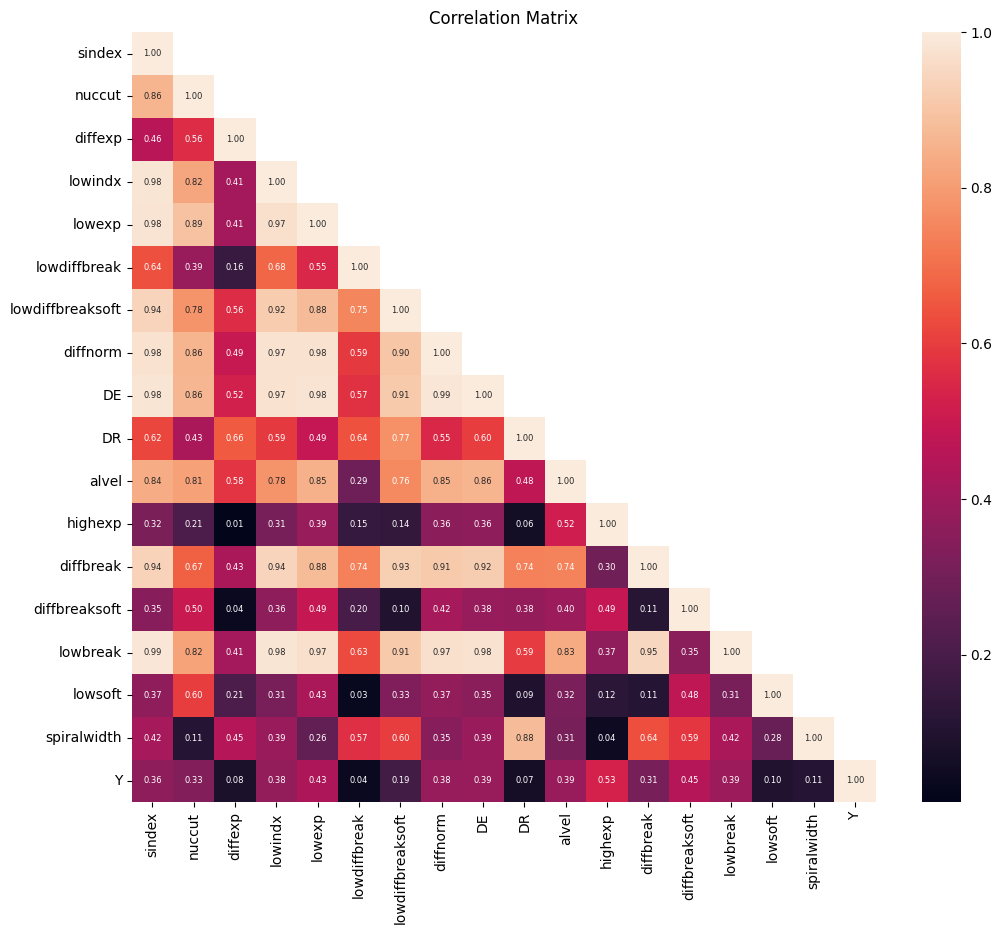

In [20]:
fig, ax = plt.subplots(figsize=(12,10))
cor_matrix = data.corr(numeric_only=True).abs()
upper_tri=cor_matrix.where(np.tril(np.ones(cor_matrix.shape), k=0).astype(bool))
ax=sns.heatmap(upper_tri, annot=True, annot_kws={"size":6}, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")

#### Histograms

array([[<Axes: title={'center': 'sindex'}>,
        <Axes: title={'center': 'nuccut'}>,
        <Axes: title={'center': 'diffexp'}>,
        <Axes: title={'center': 'lowindx'}>],
       [<Axes: title={'center': 'lowexp'}>,
        <Axes: title={'center': 'lowdiffbreak'}>,
        <Axes: title={'center': 'lowdiffbreaksoft'}>,
        <Axes: title={'center': 'diffnorm'}>],
       [<Axes: title={'center': 'DE'}>, <Axes: title={'center': 'DR'}>,
        <Axes: title={'center': 'alvel'}>,
        <Axes: title={'center': 'highexp'}>],
       [<Axes: title={'center': 'diffbreak'}>,
        <Axes: title={'center': 'diffbreaksoft'}>,
        <Axes: title={'center': 'lowbreak'}>,
        <Axes: title={'center': 'lowsoft'}>],
       [<Axes: title={'center': 'spiralwidth'}>,
        <Axes: title={'center': 'Y'}>, <Axes: >, <Axes: >]], dtype=object)

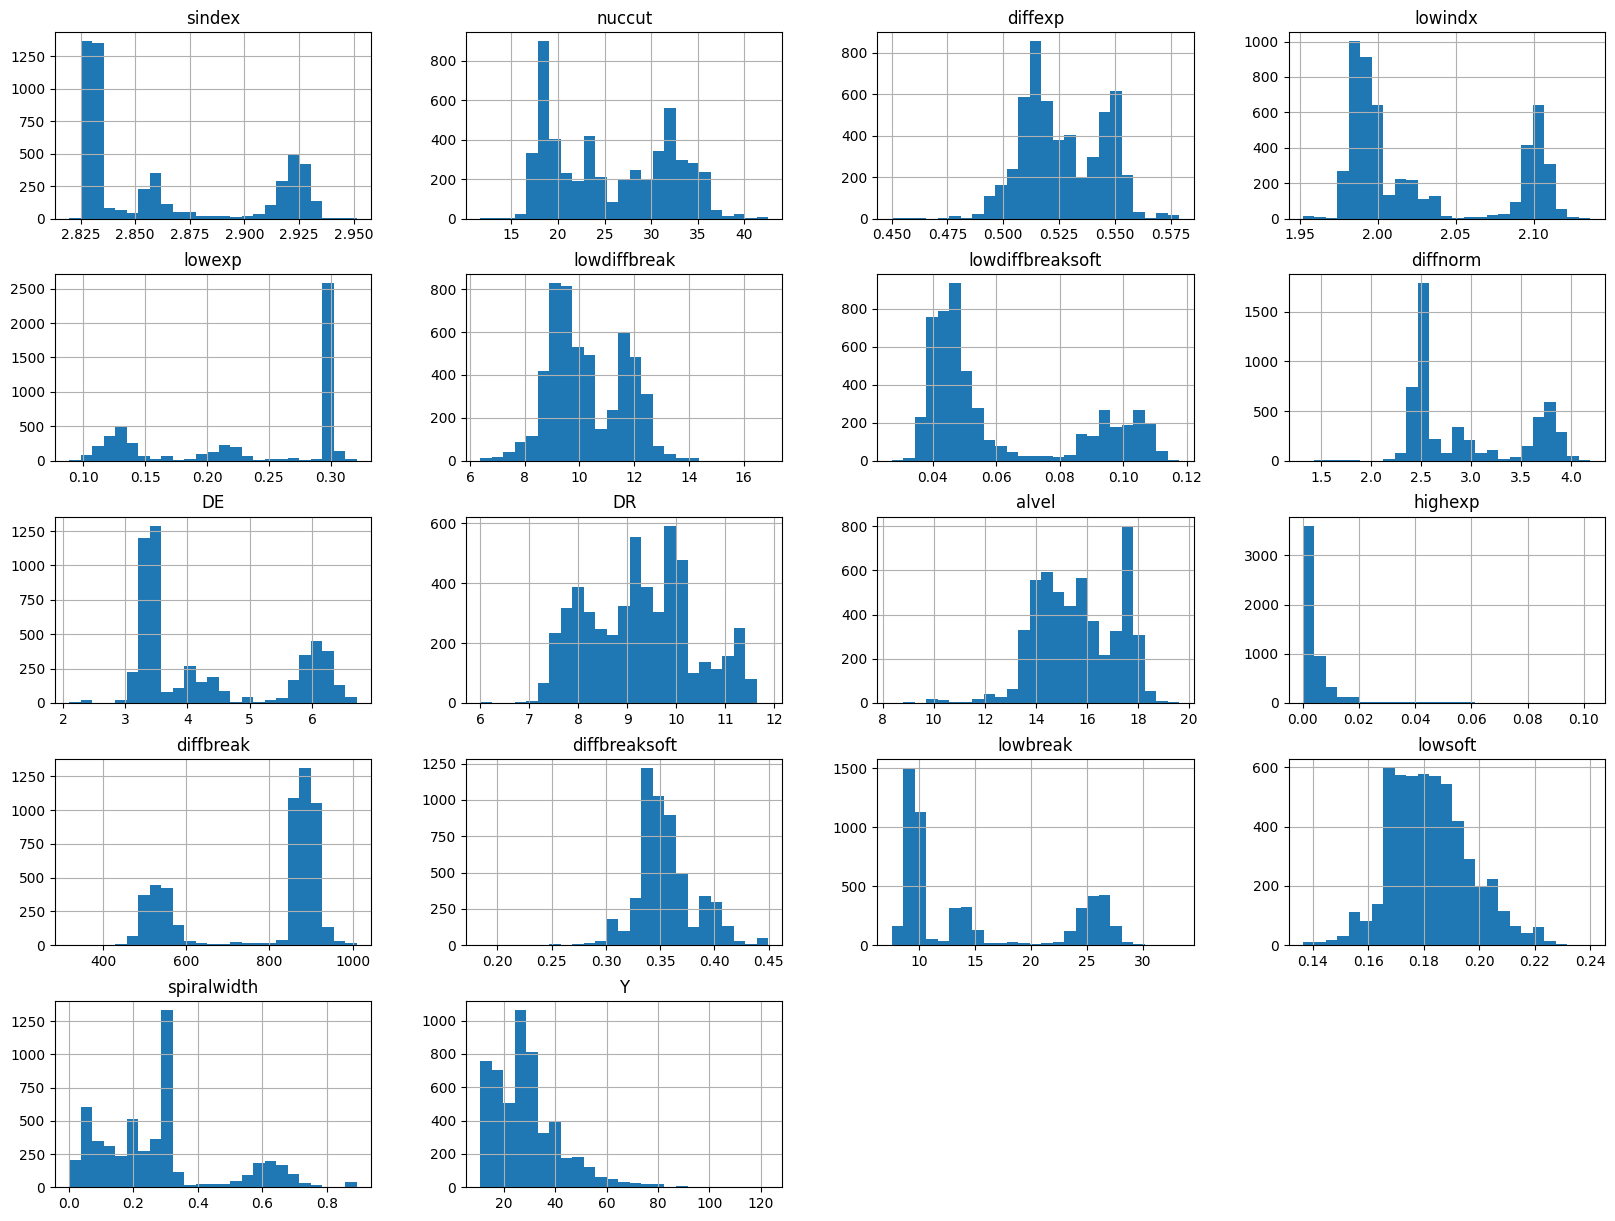

In [21]:
data.hist(bins=25, figsize=(20,15))

# sns.pairplot(data[0:1])

#### Outliers

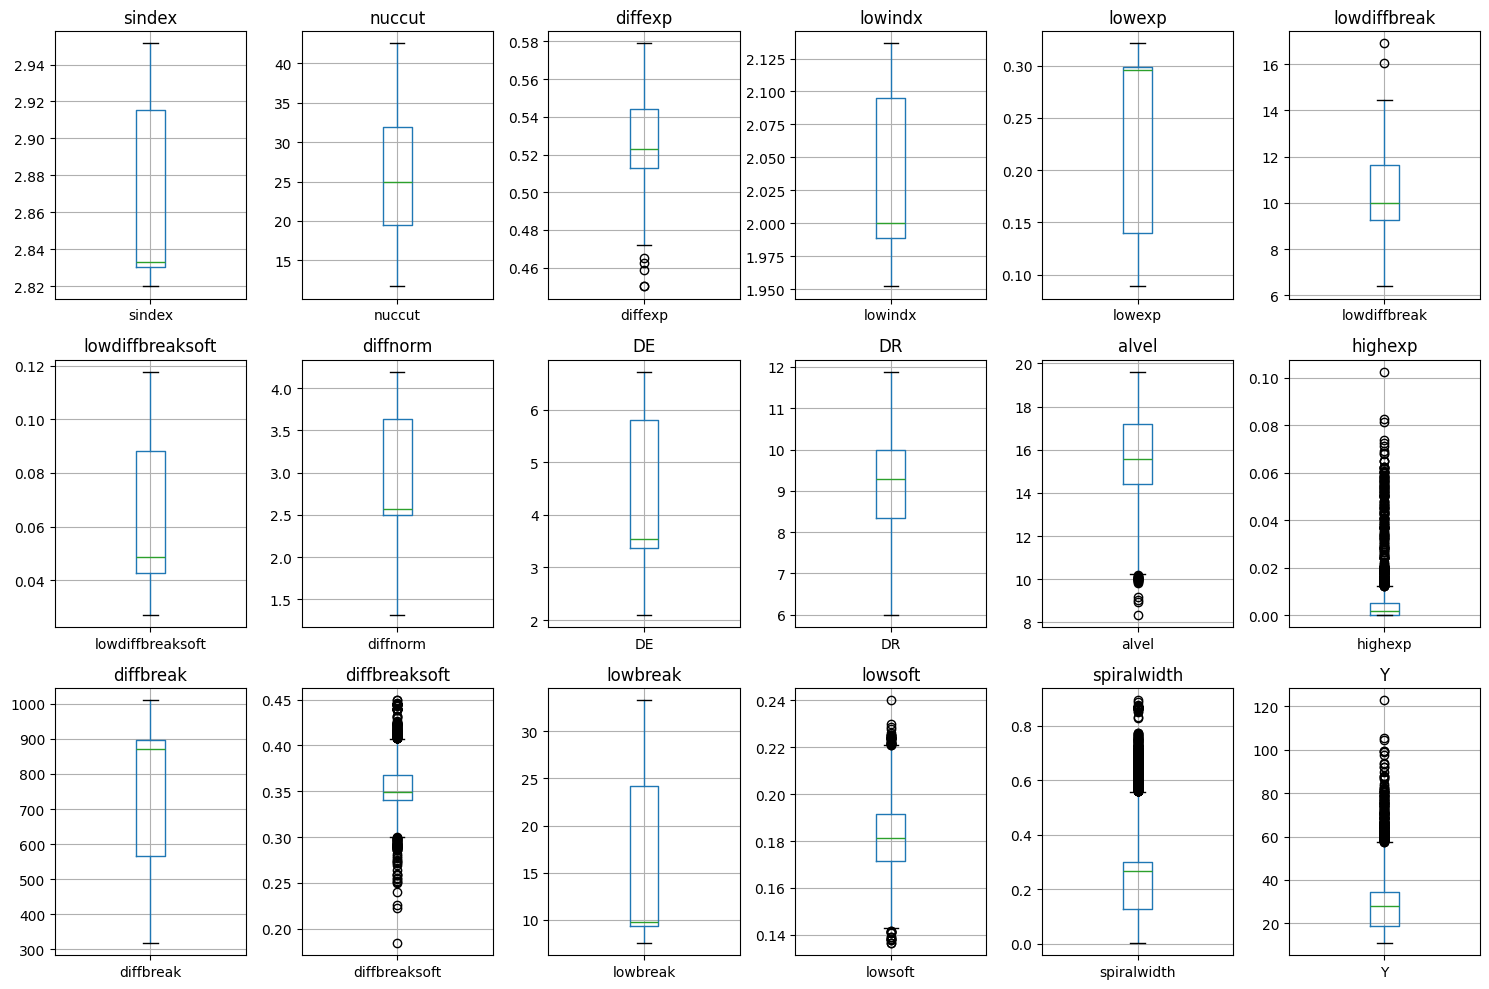

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=len(data.columns)//3 + (len(data.columns) % 3 > 0), figsize=(15, 10))

# Plot boxplots for each column
for i, column in enumerate(data.columns):
    row = i // (len(data.columns) // 3)
    col = i % (len(data.columns) // 3)
    data.boxplot(column, ax=axes[row, col])
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

### Saving Processed Data:

#### Raw Data

In [23]:
# Save X and y as Dataframes:    
ycolumns = ["Y"]
y = data[ycolumns].copy()
X = data.drop(columns=ycolumns).copy()

datadict_unsplit = {
    "X": X,
    "y": y
}
with open('Data/Raw/unsplit.pkl', 'wb') as file:
    pickle.dump(datadict_unsplit, file)
    
    
# Train-Val-Test-Split and save as Dataframes:
X_train, X_alt, y_train, y_alt = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_alt, y_alt, test_size=0.5, random_state=69)

datadict_split = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}
with open('Data/Raw/split.pkl', 'wb') as file:
    pickle.dump(datadict_split, file)

#### Transformation

In [24]:
# 1. Create a train-test-split, all conclusions drawn can only come from the training set (prevent data leakage!)
columns = data.columns
ycolumns = ["Y"]
y = data[ycolumns].copy()
X = data.drop(columns=ycolumns).copy()
Xcolumns=X.columns
X_train, X_alt, y_train, y_alt = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Standardize Data
Xscaler= StandardScaler()
ylog_trafo = FunctionTransformer(func=np.log1p, inverse_func=np.exp, check_inverse=True)
yscaler = StandardScaler()

X_train = pd.DataFrame(Xscaler.fit_transform(X_train), columns=Xcolumns)
# y_train = ylog_trafo.transform(y_train)
y_train = pd.DataFrame(yscaler.fit_transform(y_train), columns=ycolumns)
X_alt = pd.DataFrame(Xscaler.transform(X_alt), columns=Xcolumns)
# y_alt = ylog_trafo.transform(y_alt)
y_alt = pd.DataFrame(yscaler.transform(y_alt), columns=ycolumns)

joblib.dump(Xscaler, "BestModels/Transformer/Xscaler.pkl")
# joblib.dump(ylog_trafo, "BestModels/Transformer/ylog_trafo.pkl")
joblib.dump(yscaler, "BestModels/Transformer/yScaler.pkl")
 
# 3. Create Validation-Test Split & Save Data
X_val, X_test, y_val, y_test = train_test_split(X_alt, y_alt, test_size=0.5, random_state=69)

#save processed data as dataframes:
datadict_split = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}
with open('Data/Transformed/split.pkl', 'wb') as file:
    pickle.dump(datadict_split, file)

#save processed data as tensors:
class TensorDataset(Dataset):
    def __init__(self, X, y):
        # Initialize data, convert from pd df to tensor
        # Here I am already expecting pretransformed data as given above
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)   
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)
dataset_dict = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}
with open('Data/Transformed/tensor.pkl', 'wb') as file:
    pickle.dump(dataset_dict, file)

array([[<Axes: title={'center': 'sindex'}>,
        <Axes: title={'center': 'nuccut'}>,
        <Axes: title={'center': 'diffexp'}>,
        <Axes: title={'center': 'lowindx'}>],
       [<Axes: title={'center': 'lowexp'}>,
        <Axes: title={'center': 'lowdiffbreak'}>,
        <Axes: title={'center': 'lowdiffbreaksoft'}>,
        <Axes: title={'center': 'diffnorm'}>],
       [<Axes: title={'center': 'DE'}>, <Axes: title={'center': 'DR'}>,
        <Axes: title={'center': 'alvel'}>,
        <Axes: title={'center': 'highexp'}>],
       [<Axes: title={'center': 'diffbreak'}>,
        <Axes: title={'center': 'diffbreaksoft'}>,
        <Axes: title={'center': 'lowbreak'}>,
        <Axes: title={'center': 'lowsoft'}>],
       [<Axes: title={'center': 'spiralwidth'}>,
        <Axes: title={'center': 'Y'}>, <Axes: >, <Axes: >]], dtype=object)

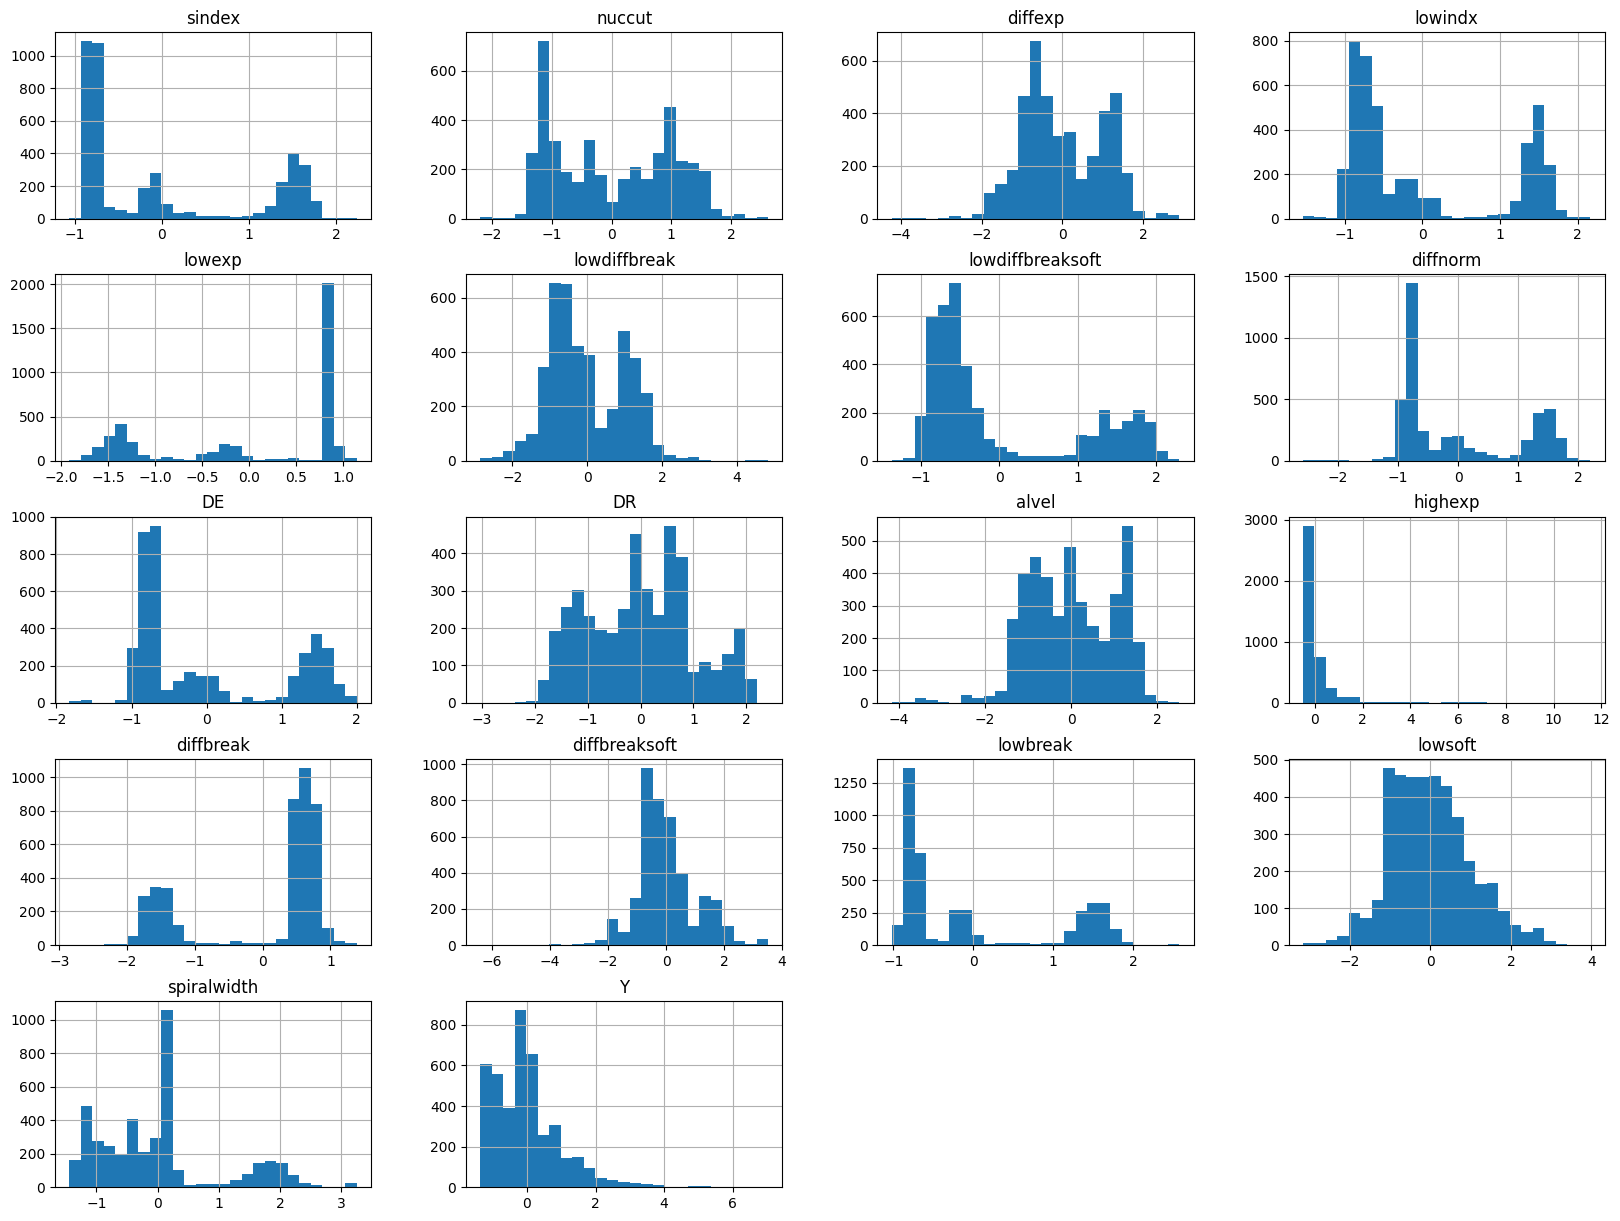

In [25]:
pd.concat([X_train, y_train]).hist(bins=25, figsize=(20,15))

In [26]:
print(np.min(y_train), np.min(y_alt), np.min(y_test))
print("Variance y:", y_train.std()**2)

-1.3584613916457842 -1.3541858848314663 -1.3541858848314663
Variance y: Y    1.000237
dtype: float64
